IMPORTING LIBRERIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style('whitegrid')

In [3]:
from pathlib import Path

data_path = (
    Path.cwd().parent
    / 'data'
    / 'cleaned'
    / 'Telco-Customer-Churn-Cleaned.csv'
)

df = pd.read_csv(data_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [22]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [23]:
df.describe(include='object')

C:\Users\HP\AppData\Local\Temp\ipykernel_13372\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


## Initial Findings

- Dataset contains 7043 customer records.
- Dataset contains both numerical and categorical variables.
- No missing values are present after cleaning.

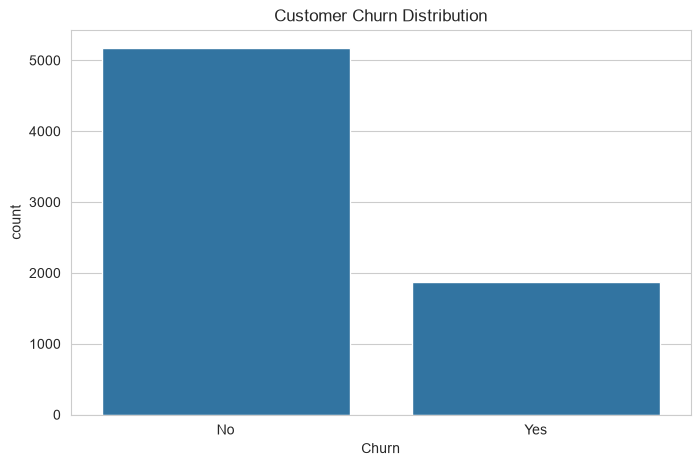

In [8]:
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

Observation:
Most customers stayed with the company, while a smaller proportion left the company.

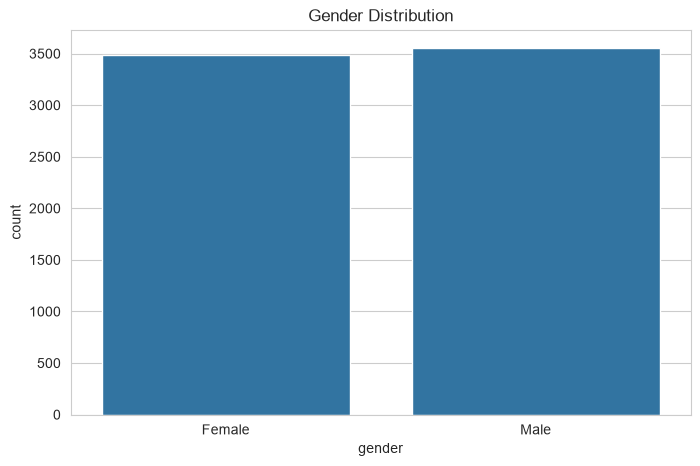

In [9]:
sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')
plt.show()

Observation:
Male and female customers are almost equally represented in the dataset.

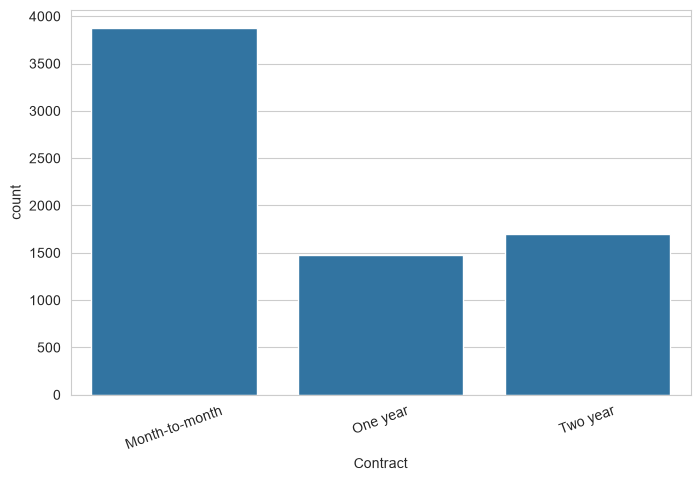

In [10]:
sns.countplot(data=df, x='Contract')
plt.xticks(rotation=20)
plt.show()

Observation:
Month-to-month contracts are more common than long-term contracts.

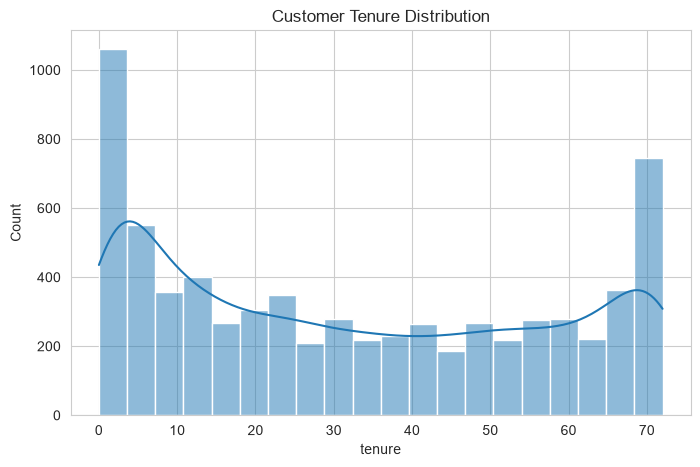

In [11]:
sns.histplot(df['tenure'], bins=20, kde=True)
plt.title('Customer Tenure Distribution')
plt.show()

Observation:
The company has both newly joined and long-term customers.

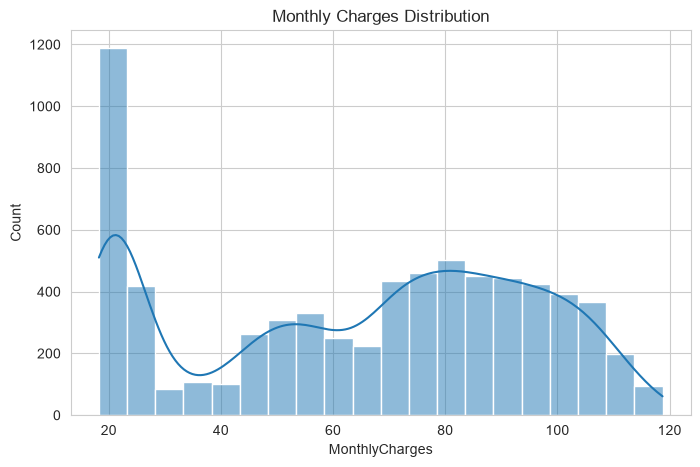

In [12]:
sns.histplot(df['MonthlyCharges'], bins=20, kde=True)
plt.title('Monthly Charges Distribution')
plt.show()

Observation:
Monthly charges vary significantly across customers due to different service plans.

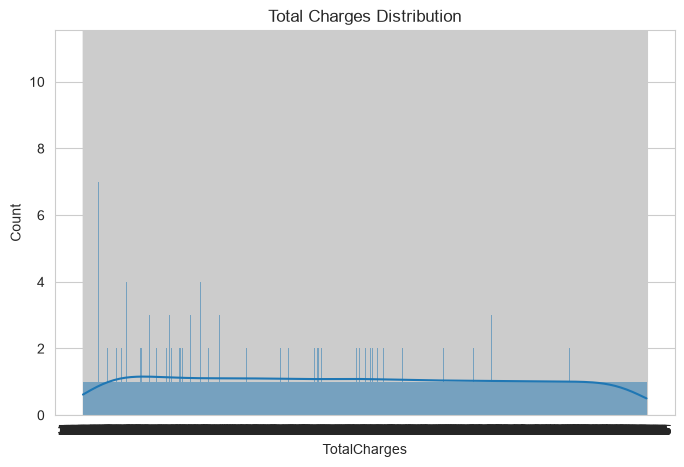

In [13]:
sns.histplot(df['TotalCharges'], bins=20, kde=True)
plt.title('Total Charges Distribution')
plt.show()

Observation:
Most customers have relatively low total charges, while long-term customers accumulate higher charges.

Churn vs Contract

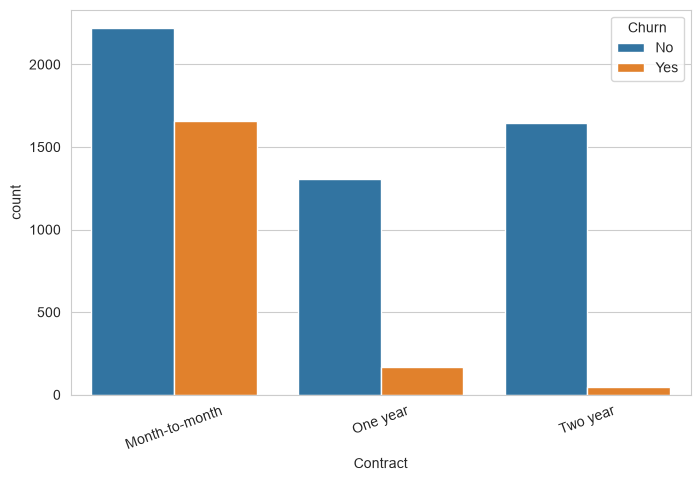

In [ ]:
sns.countplot( data=df,
    x='Contract',
    hue='Churn')
   
plt.xticks(rotation=20)
plt.show()

Observation:
Month-to-month customers show considerably higher churn compared to customers with long-term contracts.

Churn vs Internet Service

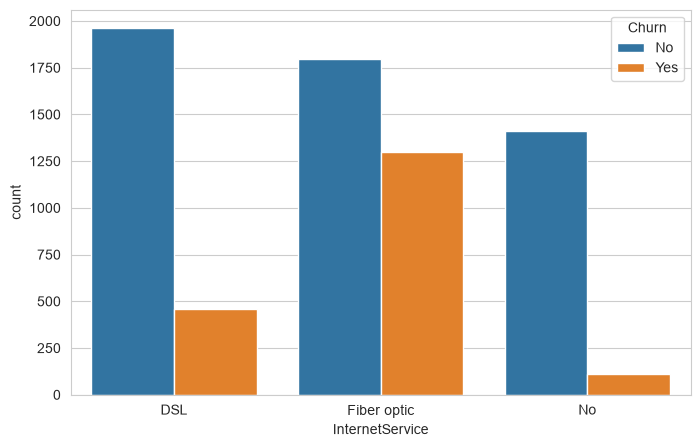

In [16]:
sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)
plt.show()

Churn vs Senior Citizen

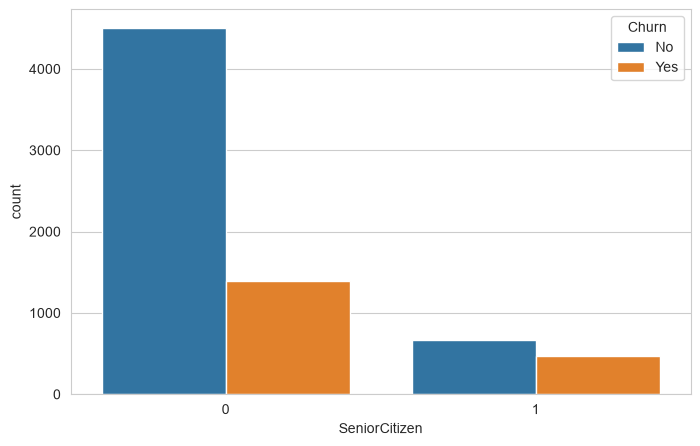

In [17]:
sns.countplot(
    data=df,
    x='SeniorCitizen',
    hue='Churn'
)
plt.show()

Observation:
Senior citizens exhibit a relatively higher churn tendency.

Monthly Charges vs Churn

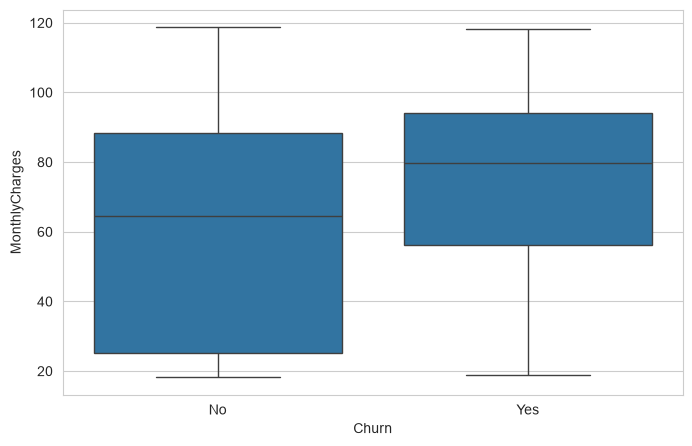

In [18]:
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)
plt.show()

Correlation Heatmap

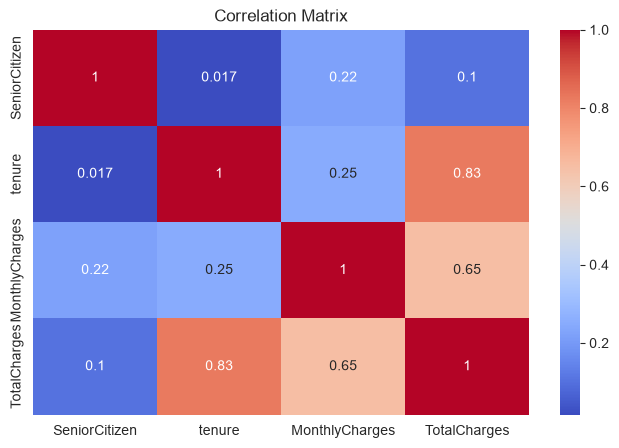

In [24]:
num_cols = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

In [26]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [27]:
df['Contract'].value_counts()


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [28]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

# Key Findings

1. Customer retention is higher than customer churn.
2. Month-to-month contracts experience significantly higher churn.
3. Fiber optic customers tend to churn more frequently.
4. Customers paying higher monthly charges are more likely to churn.
5. Long-tenure customers generate higher total charges and are generally more stable.

Conclusion:
Customer churn is strongly associated with contract type, service plans, and monthly charges. These variables are likely to be important features during machine learning model development.